# Comparing the baseline old vs the Approach 3 logic approach

This notebook compares two CSV outputs:

- **Baseline**: `filtered_pairs_500_800_HiGHS_CMD_threads_8.csv`
- **Approach 3  approach**: `filtered_pairs_500_800_HiGHS_CMD_threads_8_approach3.csv`

Main question:

> Did the Approach 3  approach give a useful lower bound and avoid going through the solver, while still producing comparable results?

The notebook checks:

1. Whether the same molecular pairs are present in both files.
2. Whether solver calls were reduced.
3. Whether the returned distances/lower bounds changed.
5. Which pairs changed behavior between the two approaches.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../../example/filter_mass_diff_and_size')
BASELINE_PATH =  DATA_DIR /'filtered_pairs_500_800_HiGHS_CMD_threads_8.csv'
Approach3_PATH = DATA_DIR /'filtered_pairs_500_800_HiGHS_CMD_threads_8_approach3.csv'

baseline = pd.read_csv(BASELINE_PATH)
Approach3  = pd.read_csv(Approach3_PATH)

print("Baseline shape:", baseline.shape)
print("Approach3 shape:", Approach3.shape)

display(baseline.head())
display(Approach3.head())

Baseline shape: (47, 18)
Approach3 shape: (47, 21)


,pair_id,smiles1,smiles2,mass1,mass2,mass_diff,runtime_sec,runtime_inside_mces,distance,compute_mode,skipped,solverCalled,ilp_solver,raw_mces_result,error_message,result_type,is_exact,is_lower_bound
0,1879,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,723.177,723.177,2.273737e-13,18.516819,16.539669,4.0,1.0,0,1,1.0,"(0, 3.99999999999941, 16.539669275283813, 1, 1)",NaN,exact,1,0
1,3585,[H][C@@](COC(=O)CCCCCCCCCCCCCCC)(COC(=O)CCCCCC...,[H][C@@](COC(=O)CCCCCCCCCCCCC(C)CC)(COC(=O)CCC...,793.312,793.312,1.136868e-13,5.443820,4.268368,4.0,1.0,0,1,1.0,"(0, 3.9999999999988765, 4.2683680057525635, 1, 1)",NaN,exact,1,0
2,3623,CC[C@H](O)\C=C\C=C/C\C=C/C\C=C/C\C=C/CCCC(=O)O...,CC1OC(CC(C1OS(C)(=O)=O)N1CC1)OC1CC(O)(CC2=C(O)...,602.897,601.630,1.267000e+00,1.123909,0.002992,25.0,2.0,0,0,NaN,"(0, 25.0, 0.0029916763305664062, 2)",NaN,lower_bound,0,1
3,7864,CCCCC[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C@@H]1C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCC)(COC(=O)CCC...,764.931,765.258,3.270000e-01,1.003926,0.001994,20.0,2.0,0,0,NaN,"(0, 20.0, 0.0019943714141845703, 2)",NaN,lower_bound,0,1
4,8016,CCCCC\C=C/C\C=C/C\C=C/CCCCC(=O)O[C@H](COC(=O)C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCC(C)C)(COC(=O)...,792.004,793.312,1.308000e+00,0.977670,0.002113,17.0,2.0,0,0,NaN,"(0, 17.0, 0.00211334228515625, 2)",NaN,lower_bound,0,1


,pair_id,smiles1,smiles2,mass1,mass2,mass_diff,runtime_sec,runtime_inside_mces,distance,compute_mode,...,solverCalled,ilp_solver,actual_threshold,structural_lb,skipped_by_structural_lb,raw_mces_result,error_message,result_type,is_exact,is_lower_bound
0,1879,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,723.177,723.177,2.273737e-13,16.921614,15.745250,4.0,1,...,1,1.0,10.0,NaN,0,"(0, 3.99999999999941, 15.745250225067139, 1, 1...",NaN,exact,1,0
1,3585,[H][C@@](COC(=O)CCCCCCCCCCCCCCC)(COC(=O)CCCCCC...,[H][C@@](COC(=O)CCCCCCCCCCCCC(C)CC)(COC(=O)CCC...,793.312,793.312,1.136868e-13,5.210119,3.966926,4.0,1,...,1,1.0,10.0,NaN,0,"(0, 3.9999999999988765, 3.966925859451294, 1, ...",NaN,exact,1,0
2,3623,CC[C@H](O)\C=C\C=C/C\C=C/C\C=C/C\C=C/CCCC(=O)O...,CC1OC(CC(C1OS(C)(=O)=O)N1CC1)OC1CC(O)(CC2=C(O)...,602.897,601.630,1.267000e+00,1.719914,0.004126,25.0,2,...,0,NaN,NaN,NaN,0,"(0, 25.0, 0.004126310348510742, 2)",NaN,lower_bound,0,1
3,7864,CCCCC[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C@@H]1C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCC)(COC(=O)CCC...,764.931,765.258,3.270000e-01,1.185744,0.001991,20.0,2,...,0,NaN,NaN,NaN,0,"(0, 20.0, 0.00199127197265625, 2)",NaN,lower_bound,0,1
4,8016,CCCCC\C=C/C\C=C/C\C=C/CCCCC(=O)O[C@H](COC(=O)C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCC(C)C)(COC(=O)...,792.004,793.312,1.308000e+00,1.243983,0.001995,17.0,2,...,0,NaN,NaN,NaN,0,"(0, 17.0, 0.0019948482513427734, 2)",NaN,lower_bound,0,1


## Merge both outputs by `pair_id`

This allows row-by-row comparison between approaches.

In [2]:
merged = baseline.merge(
    Approach3,
    on="pair_id",
    how="outer",
    suffixes=("_baseline", "_Approach3"),
    indicator=True
)

print(merged["_merge"].value_counts())
display(merged.head())

_merge
both          47
left_only      0
right_only     0
Name: count, dtype: int64


,pair_id,smiles1_baseline,smiles2_baseline,mass1_baseline,mass2_baseline,mass_diff_baseline,runtime_sec_baseline,runtime_inside_mces_baseline,distance_baseline,compute_mode_baseline,...,ilp_solver_Approach3,actual_threshold,structural_lb,skipped_by_structural_lb,raw_mces_result_Approach3,error_message_Approach3,result_type_Approach3,is_exact_Approach3,is_lower_bound_Approach3,_merge
0,1879,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,723.177,723.177,2.273737e-13,18.516819,16.539669,4.0,1.0,...,1.0,10.0,NaN,0,"(0, 3.99999999999941, 15.745250225067139, 1, 1...",NaN,exact,1,0,both
1,3585,[H][C@@](COC(=O)CCCCCCCCCCCCCCC)(COC(=O)CCCCCC...,[H][C@@](COC(=O)CCCCCCCCCCCCC(C)CC)(COC(=O)CCC...,793.312,793.312,1.136868e-13,5.443820,4.268368,4.0,1.0,...,1.0,10.0,NaN,0,"(0, 3.9999999999988765, 3.966925859451294, 1, ...",NaN,exact,1,0,both
2,3623,CC[C@H](O)\C=C\C=C/C\C=C/C\C=C/C\C=C/CCCC(=O)O...,CC1OC(CC(C1OS(C)(=O)=O)N1CC1)OC1CC(O)(CC2=C(O)...,602.897,601.630,1.267000e+00,1.123909,0.002992,25.0,2.0,...,NaN,NaN,NaN,0,"(0, 25.0, 0.004126310348510742, 2)",NaN,lower_bound,0,1,both
3,7864,CCCCC[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C@@H]1C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCC)(COC(=O)CCC...,764.931,765.258,3.270000e-01,1.003926,0.001994,20.0,2.0,...,NaN,NaN,NaN,0,"(0, 20.0, 0.00199127197265625, 2)",NaN,lower_bound,0,1,both
4,8016,CCCCC\C=C/C\C=C/C\C=C/CCCCC(=O)O[C@H](COC(=O)C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCC(C)C)(COC(=O)...,792.004,793.312,1.308000e+00,0.977670,0.002113,17.0,2.0,...,NaN,NaN,NaN,0,"(0, 17.0, 0.0019948482513427734, 2)",NaN,lower_bound,0,1,both


## Overall summary

Important columns:

- `solverCalled`: whether the ILP solver was called.
- `distance`: returned distance or lower bound.
- `compute_mode`: how the result was computed.
- `is_exact`: whether the result is exact.
- `is_lower_bound`: whether the result is only a lower bound.


In [3]:
def make_summary(df, name):
    solver_df = df[df["solverCalled"] == 1]

    return {
        "approach": name,
        "n_pairs": len(df),

        # overall solver usage
        "solver_calls": df["solverCalled"].sum(),
        "solver_call_rate": df["solverCalled"].mean(),

        # overall result types
        "exact_results_total": df["is_exact"].sum(),
        "lower_bound_results_total": df["is_lower_bound"].sum(),
        "skipped": df["skipped"].sum(),

        # result types ONLY when solver was called
        "exact_results": solver_df["is_exact"].sum(),
        "lower_bound_results": solver_df["is_lower_bound"].sum(),

        # runtime
        "mean_runtime_sec": df["runtime_sec"].mean(),
        "median_runtime_sec": df["runtime_sec"].median(),
    }


summary = pd.DataFrame([
    make_summary(baseline, "baseline"),
    make_summary(Approach3, "Approach3")
])

display(summary)

,approach,n_pairs,solver_calls,solver_call_rate,exact_results_total,lower_bound_results_total,skipped,exact_results,lower_bound_results,mean_runtime_sec,median_runtime_sec
0,baseline,47,24,0.510638,6,40,1,6,18,4.594399,2.105665
1,Approach3,47,25,0.531915,19,28,0,19,6,9.471087,3.120590


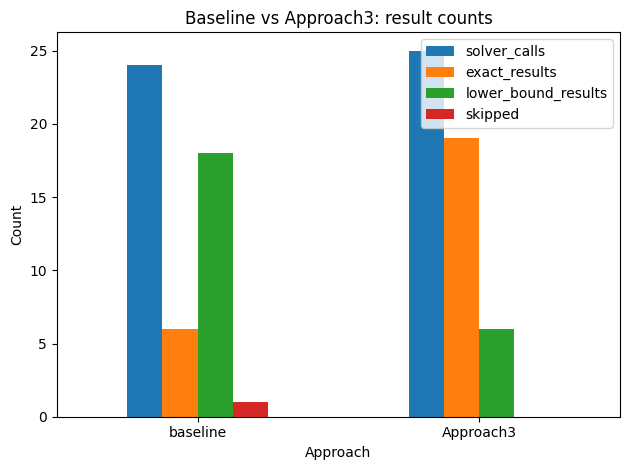

In [4]:
fig, ax = plt.subplots()
summary.set_index("approach")[["solver_calls", "exact_results", "lower_bound_results", "skipped"]].plot(kind="bar", ax=ax)
ax.set_title("Baseline vs Approach3: result counts")
ax.set_ylabel("Count")
ax.set_xlabel("Approach")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Did Approach3 avoid solver calls?

This section identifies pairs where the baseline called the solver but the Approach3 approach did not.

In [5]:
solver_change = merged.assign(
    solver_avoided = (merged["solverCalled_baseline"] == 1) & (merged["solverCalled_Approach3"] == 0),
    solver_newly_called = (merged["solverCalled_baseline"] == 0) & (merged["solverCalled_Approach3"] == 1)
)

print("Solver avoided by Approach3:", int(solver_change["solver_avoided"].sum()))
print("Solver newly called by Approach3:", int(solver_change["solver_newly_called"].sum()))

cols_to_show = [
    "pair_id",
    "distance_baseline", "distance_Approach3",
    "compute_mode_baseline", "compute_mode_Approach3",
    "solverCalled_baseline", "solverCalled_Approach3",
    "is_exact_baseline", "is_exact_Approach3",
    "is_lower_bound_baseline", "is_lower_bound_Approach3",
    "result_type_baseline", "result_type_Approach3",
    "runtime_sec_baseline", "runtime_sec_Approach3"
]
existing_cols = [c for c in cols_to_show if c in solver_change.columns]

avoided_solver_pairs = solver_change.loc[solver_change["solver_avoided"], existing_cols].copy()
display(avoided_solver_pairs)

Solver avoided by Approach3: 0
Solver newly called by Approach3: 1


,pair_id,distance_baseline,distance_Approach3,compute_mode_baseline,compute_mode_Approach3,solverCalled_baseline,solverCalled_Approach3,is_exact_baseline,is_exact_Approach3,is_lower_bound_baseline,is_lower_bound_Approach3,result_type_baseline,result_type_Approach3,runtime_sec_baseline,runtime_sec_Approach3


## Compare distances and lower bounds

Here we check whether Approach3 returned the same, higher, or lower value than the baseline.

For a lower-bound filter, a **higher lower bound** is generally stronger, as long as it does not exceed the true exact distance. If the exact solver result is unavailable, we can only compare against the baseline output, not prove correctness globally.


In [6]:
merged["distance_diff_Approach3_minus_baseline"] = merged["distance_Approach3"] - merged["distance_baseline"]

distance_summary = merged["distance_diff_Approach3_minus_baseline"].describe()
display(distance_summary)

print("Same distance:", int(np.isclose(merged["distance_baseline"], merged["distance_Approach3"], equal_nan=True).sum()))
print("Approach3 higher:", int((merged["distance_diff_Approach3_minus_baseline"] > 0).sum()))
print("Approach3 lower:", int((merged["distance_diff_Approach3_minus_baseline"] < 0).sum()))

changed_distances = merged.loc[
    ~np.isclose(merged["distance_baseline"], merged["distance_Approach3"], equal_nan=True),
    existing_cols + ["distance_diff_Approach3_minus_baseline"]
].copy()

display(changed_distances.sort_values("distance_diff_Approach3_minus_baseline"))

count    46.000000
mean      1.239130
std       2.078298
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       6.000000
Name: distance_diff_Approach3_minus_baseline, dtype: float64

Same distance: 28
Approach3 higher: 19
Approach3 lower: 0


,pair_id,distance_baseline,distance_Approach3,compute_mode_baseline,compute_mode_Approach3,solverCalled_baseline,solverCalled_Approach3,is_exact_baseline,is_exact_Approach3,is_lower_bound_baseline,is_lower_bound_Approach3,result_type_baseline,result_type_Approach3,runtime_sec_baseline,runtime_sec_Approach3,distance_diff_Approach3_minus_baseline
36,93715,4.0,5.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,2.105665,2.747821,1.0
7,31479,5.0,6.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,7.024341,20.157975,1.0
17,44757,5.0,6.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,7.368245,54.066168,1.0
11,33751,5.0,6.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,8.978576,36.611044,1.0
26,72734,5.0,6.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,6.394693,19.000555,1.0
20,47035,5.0,6.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,6.838682,56.166346,1.0
43,102018,5.0,6.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,9.195443,19.137772,1.0
32,87058,5.0,6.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,9.797898,25.282402,1.0
30,85717,4.0,6.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,4.368586,31.648500,2.0
8,31508,4.0,7.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,2.215978,9.837957,3.0


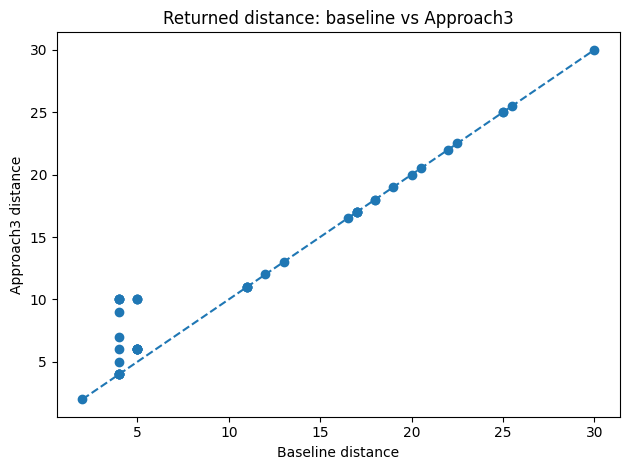

In [7]:
fig, ax = plt.subplots()
ax.scatter(merged["distance_baseline"], merged["distance_Approach3"])
min_val = np.nanmin([merged["distance_baseline"].min(), merged["distance_Approach3"].min()])
max_val = np.nanmax([merged["distance_baseline"].max(), merged["distance_Approach3"].max()])
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
ax.set_title("Returned distance: baseline vs Approach3")
ax.set_xlabel("Baseline distance")
ax.set_ylabel("Approach3 distance")
plt.tight_layout()
plt.show()

## Runtime comparison

This checks whether Approach3 is faster or slower overall, and especially for pairs where the solver was avoided.

In [8]:
merged["runtime_diff_Approach3_minus_baseline"] = merged["runtime_sec_Approach3"] - merged["runtime_sec_baseline"]

runtime_summary = merged["runtime_diff_Approach3_minus_baseline"].describe()
display(runtime_summary)

print("Approach3 faster:", int((merged["runtime_diff_Approach3_minus_baseline"] < 0).sum()))
print("Approach3 slower:", int((merged["runtime_diff_Approach3_minus_baseline"] > 0).sum()))

display(merged[[
    "pair_id",
    "runtime_sec_baseline",
    "runtime_sec_Approach3",
    "runtime_diff_Approach3_minus_baseline",
    "solverCalled_baseline",
    "solverCalled_Approach3",
    "distance_baseline",
    "distance_Approach3"
]].sort_values("runtime_diff_Approach3_minus_baseline"))

count    47.000000
mean      4.876688
std      11.329686
min      -9.281106
25%       0.173188
50%       0.596006
75%       2.498067
max      49.327664
Name: runtime_diff_Approach3_minus_baseline, dtype: float64

Approach3 faster: 4
Approach3 slower: 43


,pair_id,runtime_sec_baseline,runtime_sec_Approach3,runtime_diff_Approach3_minus_baseline,solverCalled_baseline,solverCalled_Approach3,distance_baseline,distance_Approach3
24,61065,60.000000,50.718894,-9.281106,0,1,NaN,6.0
0,1879,18.516819,16.921614,-1.595205,1,1,4.0,4.0
1,3585,5.443820,5.210119,-0.233701,1,1,4.0,4.0
16,43219,1.387822,1.298105,-0.089718,0,0,18.0,18.0
22,50640,1.018814,1.070241,0.051427,0,0,30.0,30.0
38,97962,5.553535,5.623582,0.070047,1,1,4.0,4.0
21,49642,1.093907,1.175606,0.081699,0,0,11.0,11.0
37,95805,1.320422,1.422591,0.102169,0,0,12.0,12.0
9,31991,1.007300,1.113799,0.106499,0,0,25.5,25.5
45,104071,0.950919,1.092541,0.141623,0,0,17.0,17.0


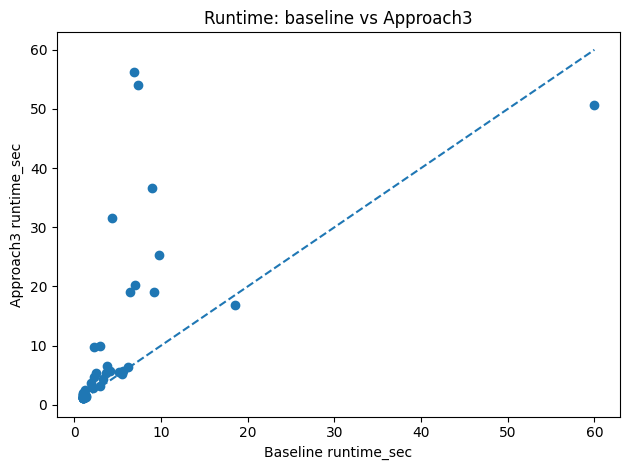

In [9]:
fig, ax = plt.subplots()
ax.scatter(merged["runtime_sec_baseline"], merged["runtime_sec_Approach3"])
min_val = np.nanmin([merged["runtime_sec_baseline"].min(), merged["runtime_sec_Approach3"].min()])
max_val = np.nanmax([merged["runtime_sec_baseline"].max(), merged["runtime_sec_Approach3"].max()])
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
ax.set_title("Runtime: baseline vs Approach3")
ax.set_xlabel("Baseline runtime_sec")
ax.set_ylabel("Approach3 runtime_sec")
plt.tight_layout()
plt.show()